# 1 Interpolation et approximation de données

## 1.1 Position du problème

### Interpolation de données

Soit $n \geq 0$ un nombre entier. Etant donnés <font color=blue> (n+1) noeuds</font> 
distincts $x_0$, $x_1$,$\dots$ $x_n$ et $(n+1)$ valeurs $y_0$,
$y_1$,$\dots$ $y_n$, on cherche un polynôme $p$
 <font color=blue>de degré $n$</font>, tel que

$$p(x_j)=y_j \qquad \text{ pour } \, 0\leq j\leq n.$$

**Exemple** On cherche le polynôme $\Pi_n$ de degré $n=4$ tel que $\Pi_n(x_j) = y_j, j =1,...,5$ avec 
les données suivantes 

| $x_k$ | $y_k$ |
| --- | --- |
| 1 | 3 |
| 1.5 | 4 |
| 2 | 2 |
| 2.5 | 5 |
| 3 | 1 |


In [1]:
# importing libraries used in this book
import numpy as np
import matplotlib.pyplot as plt

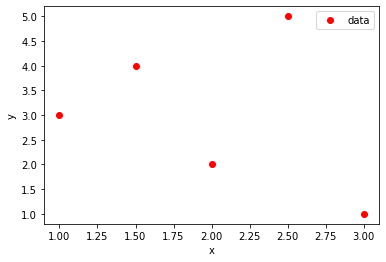

In [2]:

# Some data given: x=1, 1.5, 2, 2.5, 3 and y = 3,4,2,5,1 
x = np.linspace(1, 3, 5) # equivalent to np.array([ 1, 1.5, 2, 2.5, 3 ])
y = np.array([3, 4, 2, 5, 1])

# Plot the points using matplotlib
plt.plot(x, y, 'ro')

plt.xlabel('x'); plt.ylabel('y') #plt.title('data')
plt.legend(['data'])
plt.show()


Si ce polynôme existe, on le note $p=\Pi_n$. On appelle $\Pi_n$ le
<font color=blue>polynôme d'interpolation des valeurs $y_j$ aux noeuds $x_j,\, j=0,\dots,n$</font>.

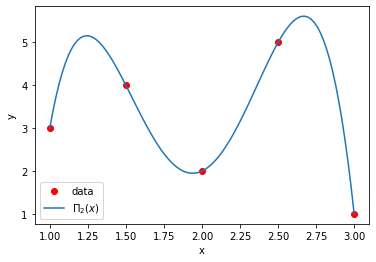

In [3]:
# Plot the interpolating function

# Defining the polynomial function 
def p(x):
    # coefficients of the interpolating polynomial
    a = np.array([-140.0, 343.0, -872./3.,  104.0,  -40./3.])
    
    # value of the polynomial in all the points t
    return  a[0] + a[1]*x + a[2]*(x**2) + a[3]*(x**3) + a[4]*(x**4)


# points used to plot the graph 
z = np.linspace(1, 3, 100)

plt.plot(x, y, 'ro', z, p(z))
plt.xlabel('x'); plt.ylabel('y'); #plt.title('data')
plt.legend(['data','$\Pi_2(x)$'])
plt.show()



### Interpolation de fonctions


Soit $f\in C^0(I)$ et $x_0,\ldots,x_n\in I$. 
Si on prend $$y_j=f(x_j),\quad 0\leq j\leq n,$$ 
alors le polynôme d'interpolation
$\Pi_n(x)$ est noté $\Pi_n f(x)$ et est appelé <font color=blue>l'interpolant de $f$ aux
noeuds $x_0$,$\dots$ $x_n$</font>.

**Exemple** Soient $$x_1=1, x_2=1.75, x_3=2.5, x_4=3.25, x_5=4$$ les points d'interpolation et $$f(x) = x \sin(2\pi x).$$ On cherche l'interpolant $\Pi_n f$ de degré $n=4$



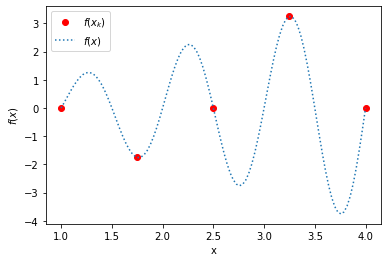

In [4]:
# defining the fonction that we want to interpolate
def f(x):
    return x*np.sin(x*2.*np.pi) 

# The interpolation must occour at points x=1, 1.75, 2.5, 3.25, 4
x = np.linspace(1, 4, 5)

# points used to plot the graph 
z = np.linspace(1, 4, 100)

plt.plot(x, f(x), 'ro', z, f(z),':')

# labels, title, legend
plt.xlabel('x'); plt.ylabel('$f(x)$'); #plt.title('data')
plt.legend(['$f(x_k)$','$f(x)$'])
plt.show()

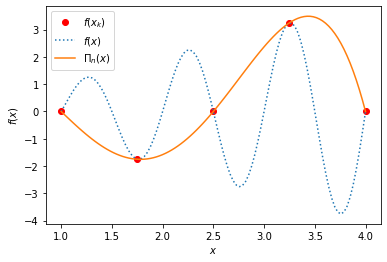

In [5]:
# Plot the interpolating function

# Defining the polynomial function 
def p(x):
    # coefficients of the interpolating polynomial
    a = np.array([0,       7.9012,      -13.037,       5.9259,     -0.79012])
    
    # value of the polynomial in all the points x
    return  a[0] + a[1]*x + a[2]*(x**2) + a[3]*(x**3) + a[4]*(x**4)


# points where to evaluate the polynomial
z = np.linspace(1, 4, 100)

plt.plot(x, f(x), 'ro', z, f(z),':', z, p(z))
plt.xlabel('$x$'); plt.ylabel('$f(x)$') #plt.title('data')
plt.legend(['$f(x_k)$','$f(x)$','$\Pi_n(x)$'])

plt.show()



### Matrice de Vandermonde

Il est possible d'écrire un système d'équations et de trouver les coefficients de manière directe.
Ce n'est pas toujours la meilleure solution.

Nous cherchons les coefficients du polynôme $p(x) = a_0 + a_1 x + ... + a_n x^n$ qui satisfont les $(n+1)$ équations $p(x_k) = y_k, k=0,...,n$, c'est-à-dire

$$a_0 + a_1 x_k + ... + a_n x_k^n = y_k, k=0,...,n$$

Ce système s'écrit sous forme matricielle

$$\begin{pmatrix}
1 & x_0 & x_0^2 & \cdots & x_0^n \\
\vdots &   &   &  & \vdots \\
1 & x_n & x_n^2 & \cdots & x_n^n
\end{pmatrix}
\begin{pmatrix} a_0 \\ \vdots \\ a_n \end{pmatrix}
=\begin{pmatrix} y_0 \\ \vdots \\ y_n \end{pmatrix}$$

Pour construire cette matrice, vous pouvez utiliser la fonction
```python
# Defining the mxn Vandermonde matrix 
def VandermondeMatrix(x):
    # Input
    # x : +1 array with interpolation nodes
    # Output
    # Matrix of Vandermonde of size n x n
```
que vous pouvez importer avec la commande
```python
from InterpolationLib import VandermondeMatrix 
```

**Exemple** On cherche les coefficients du polynôme d'interpolation de degré $n=4$ 
des valeurs suivantes 

| $x_k$ | $y_k$ |
| --- | --- |
| 1 | 3 |
| 1.5 | 4 |
| 2 | 2 |
| 2.5 | 5 |
| 3 | 1 |



In [10]:
from InterpolationLib import VandermondeMatrix 

# Some data given: x=1, 1.5, 2, 2.5, 3 and y = 3,4,2,5,1 
x = np.linspace(1, 3, 5)
y = np.array([3, 4, 2, 5, 1])
n = x.size - 1

A = VandermondeMatrix(x)
print(A)

# compute coefficients
# Resouds Ax = b avec b=y et rends x
# >>> COMPLETE HERE <<<
A2 = np.linalg.inv(A)
a = np.dot(A2,y)
# print the coefficients on screen
print('The coefficients a_0, ..., a_n are')
print(a)

[[ 1.      1.      1.      1.      1.    ]
 [ 1.      1.5     2.25    3.375   5.0625]
 [ 1.      2.      4.      8.     16.    ]
 [ 1.      2.5     6.25   15.625  39.0625]
 [ 1.      3.      9.     27.     81.    ]]
The coefficients a_0, ..., a_n are
[-140.          343.         -290.66666667  104.          -13.33333333]


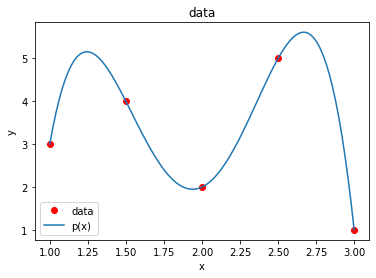

In [18]:
# Now we can define the polynomial
p = lambda x : a[0] + a[1]*x + a[2]*(x**2) + a[3]*(x**3) + a[4]*(x**4)

# points used to plot the graph 
z = np.linspace(1, 3, 100)

# Plot points and function
# >>> COMPLETE HERE <<<
plt.plot(x, p(x), 'ro', z, p(z))
plt.xlabel('x'); plt.ylabel('y'); plt.title('data')
plt.legend(['data','p(x)'])
plt.show()



### Alternatives : polyfit et polyval

Les fonctions `polyfit` et `polyval` de `numpy` font essentiellement la même chose que les paragraphes ci-dessous. Plus tard nous verrons des méthodes plus performantes.

`a = numpy.polyfit(x, y, n, ... )` :

 * input : $x,y$ les données à interpoler, $n$ le degré du polynôme recherché
 * output : les coefficients du polynôme, _dans l'ordre inverse_ de ce que nous avons vu !
 

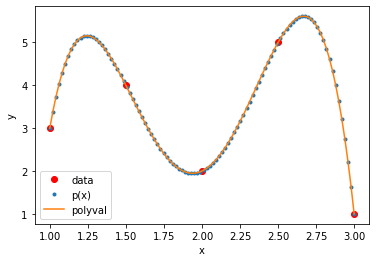

In [7]:
# Some data given: x=1, 1.5, 2, 2.5, 3 and y = 3,4,2,5,1 
x = np.linspace(1, 3, 5)
y = np.array([3, 4, 2, 5, 1])
n = x.size - 1

a = np.polyfit(x,y,n)

# Now we can define the polynomial, with coeffs in the reverse order !
p = lambda x : a[4] + a[3]*x + a[2]*(x**2) + a[1]*(x**3) + a[0]*(x**4)

# We can also use polyval instead !
# np.polyval(a,x)

# points used to plot the graph 
z = np.linspace(1, 3, 100)

plt.plot(x, y, 'ro', z, p(z), '.', z, np.polyval(a,z))
plt.xlabel('x'); plt.ylabel('y'); #plt.title('data')
plt.legend(['data','p(x)','polyval'])
plt.show()
